# *Setup*

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

from src.eda import plot_histogram, plot_boxplot, plot_bar_with_percent, plot_bar_with_percent_target, cramerv_inputs_target
from src.preprocessing import detect_empty_string, clean_data

# Análise Preliminar
#### Visão Geral do *Dataset*:
- 21 colunas, com 20 variáveis no total e 1 coluna de id;
- 7043 amostras no total;
- 1 variável de saída, `Churn`, categórica binária;
- 19 variáveis de entrada:
  - 3 variáveis numéricas, todas não negativas;
  - 16 variáveis categóricas:
    - 5 binárias;
    - 9 multiclasse com 3 classes;
    - 1 multiclasse com 4 classes;
- 4 variáveis identificando aspectos do cliente externos ao tipo de serviço ofertado;
- 15 variáveis com aspectos do tipo de serviço.

#### Observações de *Data Cleaning*:
- Remoção de `customerID`;
- Conversões:
  - `SeniorCitizen` > `object`;
  - `tenure` > `float`;
  - `TotalCharges` > `float`;
- Dados faltantes:
  - `TotalCharges`:
    - No formato de strings vazias `' '`:
    - Todos correspondentes a clientes com tempo de permanência (`tenure`) de 0 meses;
    - Valores correspondentes em `MonthlyCharges` não estão faltantes, logo, serão utilizados para preenchimento.

#### **Conclusão:**
> Etapas observadas de *data cleaning* compiladas em `src.preprocessing.clean_data`.

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [5]:
detect_empty_string(df=df)

Index(['TotalCharges'], dtype='object')

In [9]:
df.loc[np.where(df.loc[:, 'TotalCharges'] == ' ')[0]]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


# Análises Univariadas e Bivariadas
#### Observações:
- Não há *outliers*, somente se considerarmos os valores dentro da classe de saída *Yes* para `Churn`, dentro das variáveis `tenure`e `TotalCharges`;
- O *dataset* é desbalanceado: o número de clientes que deram *Churn* é, em proporção, aproximadamente 3x menor do que clientes que permanecem;
- O tipo de contrato (`Contract`) demonstra a associação mais forte com a permanência ou não:
  - Clientes com contrato anual apresentam proporção de *Churn* aproximadamente **4x** menor em relação a clientes com contrato mensal;
  - Clientes com contrato bienal apresentam proporção de *Churn* aproximadamente **15x** menor em relação a clientes com contrato mensal;
- O tipo de pagamento (`PaymentMethod`) demonstra forte associação com a permanência ou não:
  - Clientes com pagamento do tipo *Eletronic Check* apresentam proporção de *Churn* aproximadamente **3x** menor em relação aos modelos automáticos (transferência bancária e cartão de crédito) e **2x** menor em relação ao *Mailed Check*;
- O gênero do cliente (`gender`) não demonstra associação com a prática de *Churn*;
- Ter contratado ou não o serviço telefônico (`PhoneService`) não demonstra associação com a prática de *Churn*.

#### Conclusões:
> - Uma boa divisão de dados (treinamento/teste ou validação cruzada k-fold) deve preservar a proporção da classe de saída devido ao desbalanceamento;
> - Durante a avaliação dos modelos preditivos, a métrica de acurácia passa a ter uma menor importância devido ao desbalanceamento;
> - Do ponto de vista de tomada de decisão, dado que o tipo de contrato (`Contract`) e o tipo de pagamento (`PaymentMethod`) têm forte associação com a prática de *Churn*, estratégias de retenção que focam na migração do tipo do contrato para os mais estendidos e do tipo de pagamento para os automáticos devem ser experimentadas gradualmente, com a oferta de descontos e outros incentivos. É importante pontuar, no entanto, que a associação não significa causalidade, e que estas variáveis podem somente estar refletindo a verdadeira causa de menores taxas de *Churn*, em que clientes já propensos a permanecer tendem a optar por planos com maior fidelidade e modalidades de pagamento que lhes necessite menor intervenção manual;
> - Do ponto de vista de modelagem, variáveis que não demonstram associação com a prática de `Churn` podem não ser utilizadas pelos modelos devido ao menor poder discriminativo, podendo ser retiradas, simplificando em interpretabilidade, custo computacional e até mesmo melhorando a performance devido à menor chance da introdução de informações ruidosas;
> - Do ponto de vista de modelagem, os *outliers* dentro do condicionamento pela classe *Yes*, em regiões em que a classe *No* não considera como *outliers* demonstram clientes cuja tendência seria de permanência. Estratégias de retenção deveriam focar atenção em fazer clientes de alto valor total e com alto tempo de permanência no serviço se sentirem importantes e com algum status em relação aos outros.

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = clean_data(df=df)
#df.to_csv('../data/processed/WA_Fn-UseC_-Telco-Customer-Churn_for-predictive-modelling.csv')
display(df.head())
display(df.info())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


None

## Variáveis Numéricas

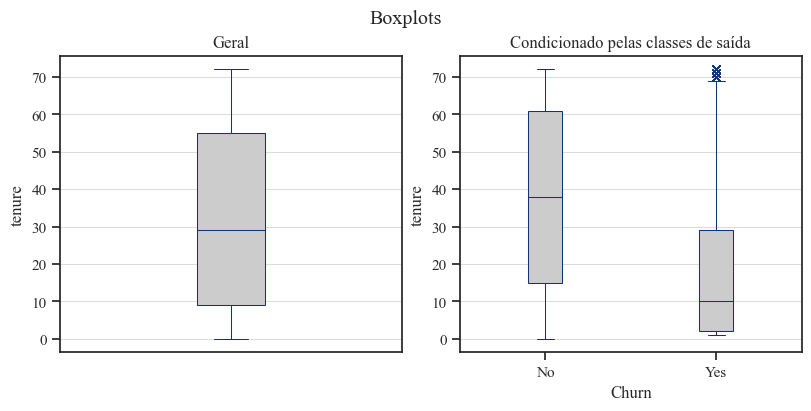

In [4]:
plot_boxplot(df=df, feature_name='tenure', save=True, path='../reports/figures/boxplot_tenure.png')

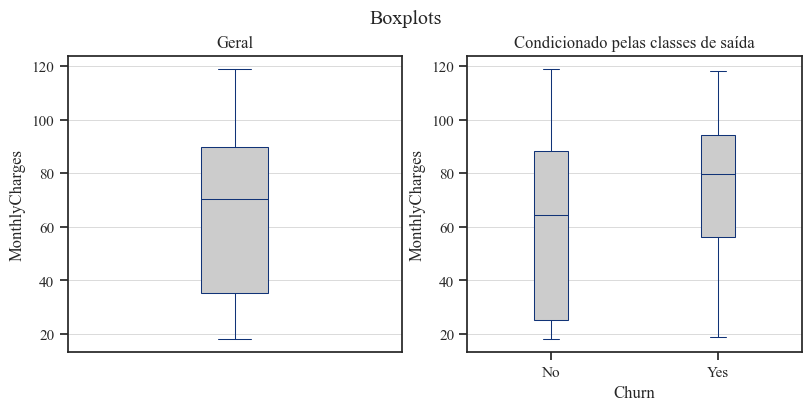

In [5]:
plot_boxplot(df=df, feature_name='MonthlyCharges', save=True, path='../reports/figures/boxplot_MonthlyCharges.png')

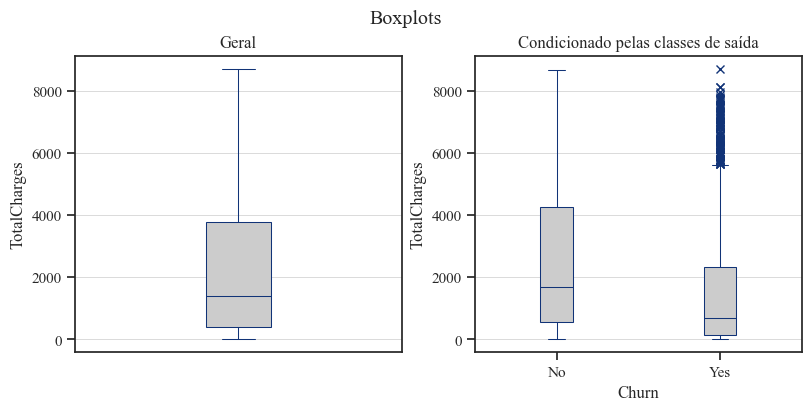

In [6]:
plot_boxplot(df=df, feature_name='TotalCharges', save=True, path='../reports/figures/boxplot_TotalCharges.png')

## Variáveis Categóricas

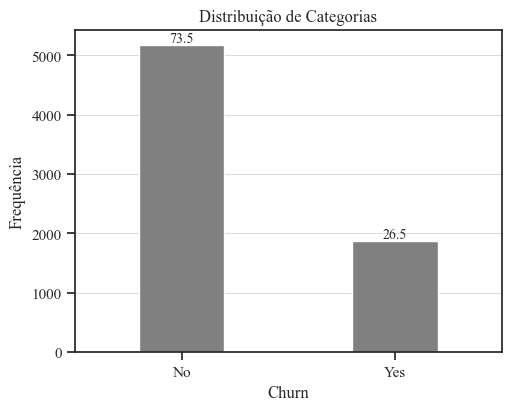

In [10]:
plot_bar_with_percent_target(df=df, save=True, path='../reports/figures/barplot_Churn.png')

In [3]:
cramerv_inputs_target(df=df.loc[:, df.dtypes=='object'], target_column='Churn',
                      style_format='standard', significance=0.05, save=True, path='../reports/tables/chi2-test_results.csv')

,V,Chi2,p-value,Degrees of Freedom,Association's Degree
Contract,0.4101,1184.6,0.000,2,strong
OnlineSecurity,0.3474,850.,0.000,2,strong
TechSupport,0.3429,828.2,0.000,2,strong
InternetService,0.3225,732.31,0.000,2,strong
PaymentMethod,0.3034,648.14,0.000,3,strong
OnlineBackup,0.2923,601.81,0.000,2,strong
DeviceProtection,0.2816,558.42,0.000,2,strong
StreamingMovies,0.2310,375.66,0.000,2,moderate
StreamingTV,0.2305,374.20,0.000,2,moderate
PaperlessBilling,0.1915,258.28,0.000,1,weak


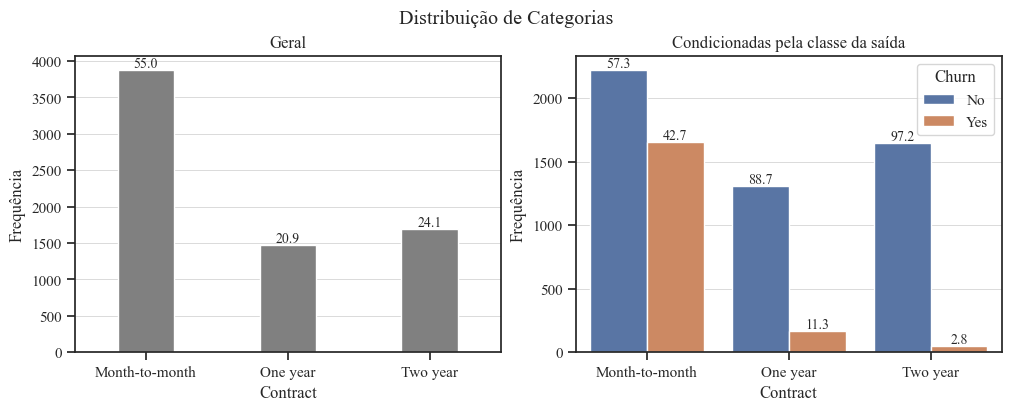

In [11]:
plot_bar_with_percent(df=df, feature_name='Contract', save=True, path='../reports/figures/barplot_Contract_Churn.png')

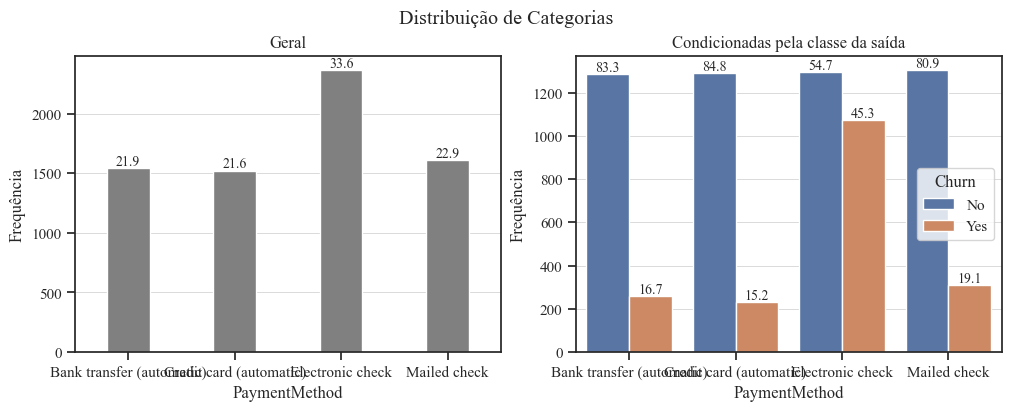

In [4]:
plot_bar_with_percent(df=df, feature_name='PaymentMethod', save=True, path='../reports/figures/barplot_PaymentMethod_Churn.png')

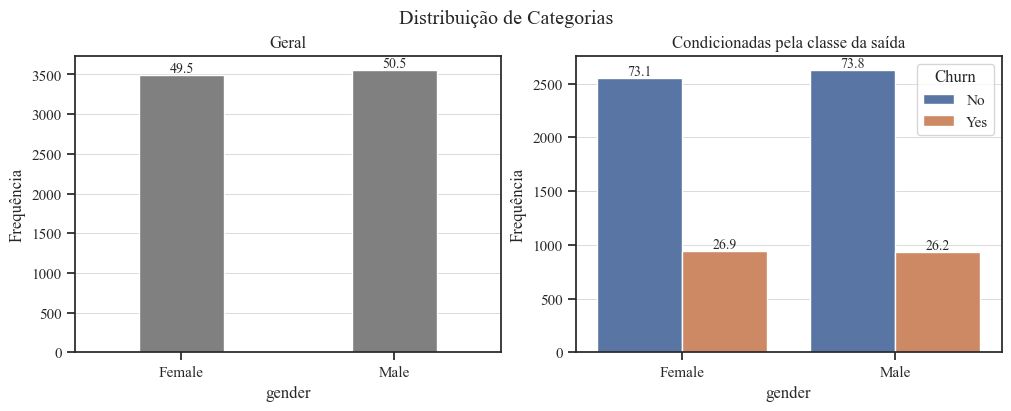

In [11]:
plot_bar_with_percent(df=df, feature_name='gender', save=True, path='../reports/figures/barplot_gender_Churn.png')

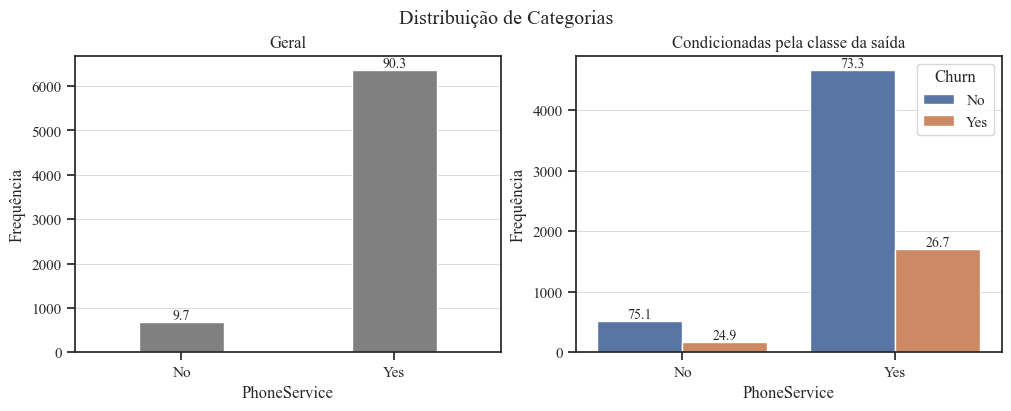

In [12]:
plot_bar_with_percent(df=df, feature_name='PhoneService', save=True, path='../reports/figures/barplot_PhoneService_Churn.png')